## Anaylse day 3 clinical results

In [1]:
import os
import re
import datetime
import pandas as pd
import numpy as np

pd.options.mode.chained_assignment = None 
import seaborn as sns
import scipy.stats as ss

from dataclasses import dataclass

import statsmodels.formula.api as smf
import statsmodels.api as sm
from firthmodels.adapters.statsmodels import FirthLogit # for regularised regression
from statsmodels.stats.proportion import proportion_confint

import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D
from matplotlib.gridspec import GridSpec

In [2]:
# Global font size parameters -- aim to produce plots at correct size
mpl.rcParams['font.size'] = 8  # base font size
# mpl.rcParams['axes.titlesize'] = 16
# mpl.rcParams['axes.labelsize'] = 14
# mpl.rcParams['xtick.labelsize'] = 12
# mpl.rcParams['ytick.labelsize'] = 12
# mpl.rcParams['legend.fontsize'] = 12
# mpl.rcParams['figure.titlesize'] = 18

## Settings

In [3]:
DIR_FIGS = "../figures/fig4"
DIR_TABLES = "../tables"
os.makedirs(DIR_FIGS, exist_ok=True)
save_results = True

In [4]:
W = 3.4 # roughly width of one column

In [5]:
P = lambda n, N: f"{n} ({100*n/N:.2f}%) of {N}"

## Functions and Globals

In [6]:
INDEX_NAMES = {
    "n_patients": "N",
    "age": "Median Age (IQR) - yr",
    "fever": "Fever - n (%)",
    "sex_female": "Female sex - n (%)",
    "day0_parasite_density_thousands": "Median parasity density (IQR) - mm$^3$",
    "prevalence": "Prevalence of A724E (95% CI) - %",
    "mutant_A724E": "724E (Mutant)",
    "wildtype_A724E": "724A (Wildtype)"
}
COLUMN_NAMES = {
    "complete": "Retained", 
    "lost": "Lost", 
    True: "Positive on Day 3",
    False: "Negative on Day 3",
    "test": "Test", 
    "pvalue": "P"
}
COVARIATE_NAMES = {"C(sex)[T.M]": "Sex",
                   "C(fever)[T.Yes]": "Fever",
                   "age": "Age",
                   "day0_parasite_density_log10": "Parasity density [log10]",
                   "const": "Intercept",
                   "sex_M": "Sex",
                   "fever_Yes": "Fever",
                   "724_mutant": "724E (Mutant)"
}

##### Descriptive

In [7]:
def get_median_and_iqrs(x: np.ndarray) -> str:
    med = np.nanmedian(x)
    iqrs = np.nanquantile(x, [0.25, 0.75])
    return f"{med:.1f} ({iqrs[0]:.1f} - {iqrs[1]:.1f})"

In [8]:
def get_number_and_percent(x: np.ndarray, val: str) -> str:
    N = x.shape[0]
    n = (x == val).sum()
    return f"{n} ({100*n/N:.1f})"

In [9]:
def get_mutation_prevalence_and_cis(x) -> str:
    # Remove missing
    x = x.dropna()
    
    # Genotypes
    n_passed = (x != './.').sum()
    n_wt = (x == '0/0').sum()
    n_mixed = (x == '0/1').sum()
    n_mut = (x == '1/1').sum()

    # Prevalence and CIs
    prev = 100 * (n_mut + n_mixed) / n_passed
    low, high = proportion_confint(
        n_mut + n_mixed,
        n_passed,
        alpha=0.05,
        method="beta",
    )

    return f"{prev:.1f} ({100*low:.1f}-{100*high:.1f})"

##### Hypothesis testing

In [10]:
class HypothesisTester:
    def __init__(self, groups: str, data: pd.DataFrame) -> None:
        self.groups = groups
        self.data = data
    
    def mannu(self, factor: str) -> float:
        """ Mann-Whitney U Test"""
        values = [list(df[factor]) for _, df in self.data.groupby(self.groups)]
        return ss.mannwhitneyu(*values, nan_policy='omit')

    def chisq(self, factor: str) -> float:
        """ Chi-squared Test"""
        return ss.chi2_contingency(pd.crosstab(self.data[self.groups], self.data[factor]))

    def fisher(self, factor: str) -> float:
        return ss.fisher_exact(pd.crosstab(self.data[self.groups], self.data[factor]))

In [11]:
@dataclass
class UniResult:
    variable: str
    test: str
    pvalue: float

    def __post_init__(self):
        self.pvalue = round(self.pvalue, 3) if isinstance(self.pvalue, float) else self.pvalue

In [12]:
def convert_logistic_to_output_table(model, covariate_map: dict[str, str] = COVARIATE_NAMES) -> pd.DataFrame:
    """
    Convert the output of a logistic regression to a clean table for publication
    
    """

    # Extract odds ratios
    OR = np.exp(model.params)

    # Get confidence intervals
    if isinstance(model.conf_int(), pd.DataFrame):
        low, high = np.exp(model.conf_int()[0]), np.exp(model.conf_int()[1])
    elif isinstance(model.conf_int(), np.ndarray):
        low, high = np.exp(model.conf_int()[:, 0]), np.exp(model.conf_int()[:, 1])
        
    # Prepare table
    df = pd.DataFrame({
        "Covariate": model.model.exog_names,
        "Coefficient (SE)": [f"{round(c, 2)} ({round(se, 2)})" for c, se in zip(model.params, model.bse)],
        "Odds Ratio (95% CI)": [f"{round(o, 1)} ({round(l, 1)}-{round(h, 1)})" for o, l, h in zip(OR, low, high)],
        "P": [round(p, 3) for p in model.pvalues]
    })
    
    df.set_index("Covariate", inplace=True)
    df.rename(covariate_map, inplace=True)
    
    return df

## Load and filter data

In [13]:
df = pd.read_csv(f"{DIR_FIGS}/ceadriz.merged.csv")

In [14]:
ct_filter = pd.crosstab(
    df["status"],
    df["day0_seqdone"],
    margins=True,
    dropna=False,
)
ct_filter

day0_seqdone,False,True,All
status,,,
complete,5,98,103
lost,8,77,85
not_enrolled,105,13,118
All,118,188,306


In [15]:
N = ct_filter['All']['complete']
n = ct_filter[True]['complete']
n_pos = df.query("status == 'complete'")["day3_pos"].sum()
n_pos_seq0 = df.query("status == 'complete' and day3_pos")["day0_seqdone"].sum()
n_pos_seq3 = df.query("status == 'complete' and day3_pos")["day3_seqdone"].sum()
print(f"""
We have {P(N, ct_filter['All']['All'] - ct_filter['All']['not_enrolled'])} participants who returned on day 3.
  {P(n_pos, N)} had parasites dectable by microscopy.
  {P(n, N)} having sequencing data for day 0.

Of the day 3 positive samples, 
  {P(n_pos_seq0, n_pos)} have sequencing complete for day 0.
  {P(n_pos_seq3, n_pos)} have sequencing complete for day 3.
""")


We have 103 (54.79%) of 188 participants who returned on day 3.
  21 (20.39%) of 103 had parasites dectable by microscopy.
  98 (95.15%) of 103 having sequencing data for day 0.

Of the day 3 positive samples, 
  21 (100.00%) of 21 have sequencing complete for day 0.
  17 (80.95%) of 21 have sequencing complete for day 3.



### Assess whether there is any bias in the lost to follow up

In [16]:
df_enrolled = df.query("status != 'not_enrolled'")
df_enrolled["status"].value_counts(dropna=False)

status
complete    103
lost         85
Name: count, dtype: int64

In [17]:
pd.crosstab(
    df_enrolled["status"],
    df_enrolled["day0_a724_mutant"],
    margins=True,
    dropna=False
)

day0_a724_mutant,mutant,wildtype,NaN,All
status,,,,
complete,75,23,5,103
lost,63,14,8,85
All,138,37,0,188


##### Univariate analysis

In [18]:
_df_bias = (df_enrolled.groupby("status")
    .agg(
        n_patients=pd.NamedAgg("sample_id", lambda x: len(x)),
        age = pd.NamedAgg("age", get_median_and_iqrs),
        day0_parasite_density_thousands = pd.NamedAgg("day0_parasite_density", lambda x: get_median_and_iqrs(x/10**3)),
        sex_female=pd.NamedAgg("sex", lambda x: get_number_and_percent(x, "F")),
        fever=pd.NamedAgg("fever", lambda x: get_number_and_percent(x, "Yes")), 
        prevalence=pd.NamedAgg("day0_a724_gt", get_mutation_prevalence_and_cis),
        # n_mixed=pd.NamedAgg("day0_a724_gt", lambda x: get_number_and_percent(x, '0/1')),
        # n_mut=pd.NamedAgg("day0_a724_gt", lambda x: get_number_and_percent(x, '1/1')),
    )
).transpose()

In [19]:
tester = HypothesisTester(data=df_enrolled, groups="status")
tester_seqdata = HypothesisTester(data=df_enrolled.query("day0_seqdone"), groups="status")
_df_stats = pd.DataFrame(
    [
        UniResult("n_patients", "-", "-"),
        UniResult("age", "Mann-Whitney $U$", tester.mannu("age").pvalue),
        UniResult("day0_parasite_density_thousands", "Mann-Whitney $U$", tester.mannu("day0_parasite_density").pvalue),
        UniResult("sex_female", "$X^2$", tester.chisq("sex").pvalue),
        UniResult("fever", "$X^2$", tester.chisq("fever").pvalue),
        UniResult("prevalence", "$X^2$", tester_seqdata.chisq("day0_a724_mutant").pvalue),
    ]
)
_df_stats.set_index('variable', inplace=True)

In [20]:
df_lost_bias = pd.concat([_df_bias, _df_stats], axis=1)
df_lost_bias = df_lost_bias.rename(INDEX_NAMES).rename(COLUMN_NAMES, axis=1)
df_lost_bias

,Retained,Lost,Test,P
N,103,85,-,-
Median Age (IQR) - yr,12.0 (6.2 - 17.0),11.5 (6.0 - 20.0),Mann-Whitney $U$,0.853
Median parasity density (IQR) - mm$^3$,26.4 (14.0 - 54.8),29.3 (9.7 - 52.9),Mann-Whitney $U$,0.564
Female sex - n (%),54 (52.4),39 (45.9),$X^2$,0.503
Fever - n (%),23 (22.3),14 (16.5),$X^2$,0.362
Prevalence of A724E (95% CI) - %,76.5 (66.9-84.5),81.8 (71.4-89.7),$X^2$,0.507


In [21]:
if save_results:
    df_lost_bias.to_csv(f"{DIR_TABLES}/stable_ceadriz-lost-bias.csv")
    df_lost_bias.to_excel(f"{DIR_TABLES}/stable_ceadriz-lost-bias.xlsx")

##### Multivariate analysis

In [22]:
# Prepare variables for multivaraiate analysis
df_enrolled["outcome"] = df_enrolled["status"].map({"complete": 0, "lost": 1})
df_enrolled["day0_a724_gt_int"] = df_enrolled["day0_a724_gt"].map({"./.": None, "0/0": 0, "0/1": 1, "1/1": 2})

# Fit model and display
model = smf.logit(
    "outcome ~ age + day0_parasite_density_log10 + C(sex) + C(fever) + day0_a724_gt_int",
    data=df_enrolled
).fit()
print(model.summary2())

Optimization terminated successfully.
         Current function value: 0.679438
         Iterations 4
                              Results: Logit
Model:                   Logit               Method:              MLE     
Dependent Variable:      outcome             Pseudo R-squared:    0.008   
Date:                    2026-08-24 19:48    AIC:                 233.4969
No. Observations:        163                 BIC:                 252.0594
Df Model:                5                   Log-Likelihood:      -110.75 
Df Residuals:            157                 LL-Null:             -111.63 
Converged:               1.0000              LLR p-value:         0.88177 
No. Iterations:          4.0000              Scale:               1.0000  
--------------------------------------------------------------------------
                             Coef.  Std.Err.    z    P>|z|   [0.025 0.975]
--------------------------------------------------------------------------
Intercept                   

In [23]:
df_lost_logit = convert_logistic_to_output_table(model)
df_lost_logit

,Coefficient (SE),Odds Ratio (95% CI),P
Covariate,,,
Intercept,1.19 (1.78),3.3 (0.1-107.9),0.502
Sex,0.05 (0.32),1.1 (0.6-2.0),0.878
Fever,-0.3 (0.41),0.7 (0.3-1.7),0.460
Age,-0.01 (0.02),1.0 (1.0-1.0),0.467
Parasity density [log10],-0.27 (0.39),0.8 (0.4-1.6),0.495
day0_a724_gt_int,-0.07 (0.22),0.9 (0.6-1.4),0.758


- The intercept is not meaningful, and should probably be dropped

In [24]:
if save_results:
    df_lost_logit.to_excel(f"{DIR_TABLES}/stable_ceadriz-lost-logit.xlsx")
    df_lost_logit.to_latex(f"{DIR_TABLES}/stable_ceadriz-lost-logit.tex", index=True)

- Include the summary text here
- Write the file as supplementary table

## Checking for an association between A724E and day 3 positivity

##### Statistical evaluation
- First, once more, let's breakdown what actually gets included in the following analysis
- Then we can do this clean fishers exact, and write table
- Then the full univariate
- Then the multivariate

In [25]:
N_enrolled = df_enrolled.shape[0]
N_complete = df_enrolled.query("status == 'complete'").shape[0]

N_day0seq = df_enrolled.query("status == 'complete' and day0_seqdone").shape[0]
N_day0passed = df_enrolled.query("status == 'complete' and day0_seqdone and day0_a724_mutant != 'failed'").shape[0]

N_day3pos = df_enrolled.query("status == 'complete' and day3_pos").shape[0]
N_day3posseq = df_enrolled.query("status == 'complete' and day3_pos and day0_seqdone").shape[0]
N_day3posseqpass = df_enrolled.query("status == 'complete' and day3_pos and day0_seqdone and day0_a724_mutant != 'failed'").shape[0]

In [26]:
df_filter = (df_enrolled
    .query("status == 'complete'") # returned
    .query("day0_seqdone") # sequenced 
    .query("day0_a724_mutant != 'failed'") # passed QC
)
df_filter["infection_rate"] = df_filter["infection_rate"].astype(float) # do this in clean!

In [27]:
print(f"""
Inclusion for day 3 association with genotype:

Recall, we have {P(N_enrolled, df.shape[0])} patients enrolled.
Of those enrolled, {P(N_complete, N_enrolled)} returned on day 3.
Of those returning patients:
    {P(N_day0seq, N_complete)} have sequencing complete on day 0.
    {P(N_day0passed, N_day0seq)} are passing QC.
    {P(N_day3pos, N_complete)} are day 3+.
    {P(N_day3posseq, N_day3pos)} are day 3+ and have day 0 sequencing.
    {P(N_day3posseqpass, N_day3posseq)} are passing sequencing QC.

These {N_day0passed} are what are used in the analysis to look for an association between A724E and day 3 positivity.
""")


Inclusion for day 3 association with genotype:

Recall, we have 188 (61.44%) of 306 patients enrolled.
Of those enrolled, 103 (54.79%) of 188 returned on day 3.
Of those returning patients:
    98 (95.15%) of 103 have sequencing complete on day 0.
    98 (100.00%) of 98 are passing QC.
    21 (20.39%) of 103 are day 3+.
    21 (100.00%) of 21 are day 3+ and have day 0 sequencing.
    21 (100.00%) of 21 are passing sequencing QC.

These 98 are what are used in the analysis to look for an association between A724E and day 3 positivity.



##### Fisher's Exact Test

In [28]:
ct_day3 = pd.crosstab(
    df_filter["day0_a724_mutant"],
    df_filter["day3_pos"],
    margins='All',
)
ct_day3_nomarg = pd.crosstab(
    df_filter["day0_a724_mutant"],
    df_filter["day3_pos"]
)
ct_day3 # clean this table, and write it

day3_pos,False,True,All
day0_a724_mutant,,,
mutant,54,21,75
wildtype,23,0,23
All,77,21,98


In [29]:
print(f"""
        Pre-treatment prevalence of:
          A724E: {P(ct_day3.loc['mutant']['All'], ct_day3.loc['All']['All'])}
          WT: {P(ct_day3.loc['wildtype']['All'], ct_day3.loc['All']['All'])}

        Day-3 positive prevalence of:
          A724E: {P(ct_day3.loc['mutant'][True], ct_day3.loc['All'][True])}
          WT: {P(ct_day3.loc['wildtype'][True], ct_day3.loc['All'][True])}

        Day-3 positivity rate by genotype:
            A724E:  {P(ct_day3.loc['mutant'][True], ct_day3.loc['mutant']['All'])}
            WT:  {P(ct_day3.loc['wildtype'][True], ct_day3.loc['wildtype']['All'])}
""")


        Pre-treatment prevalence of:
          A724E: 75 (76.53%) of 98
          WT: 23 (23.47%) of 98

        Day-3 positive prevalence of:
          A724E: 21 (100.00%) of 21
          WT: 0 (0.00%) of 21

        Day-3 positivity rate by genotype:
            A724E:  21 (28.00%) of 75
            WT:  0 (0.00%) of 23



In [30]:
ct_day3_nomarg

day3_pos,False,True
day0_a724_mutant,,
mutant,54,21
wildtype,23,0


In [31]:
ss.fisher_exact(ct_day3_nomarg) #

SignificanceResult(statistic=np.float64(0.0), pvalue=np.float64(0.0026872130633147726))

- So using a Fisher's exact test, there is a very clear association between A724E and day 3 positivity

##### Univariate analysis
- We are looking for associations between our baseline characteristics and day 3 positivity
- We are doing this in a univariate fashion

In [32]:
df_filter["day0_a724_mutant"].value_counts()

day0_a724_mutant
mutant      75
wildtype    23
Name: count, dtype: int64

In [33]:
_df_bias = (df_filter.groupby("day3_pos")
    .agg(
        n_patients=pd.NamedAgg("sample_id", lambda x: len(x)),
        age = pd.NamedAgg("age", get_median_and_iqrs),
        day0_parasite_density_thousands = pd.NamedAgg("day0_parasite_density", lambda x: get_median_and_iqrs(x/10**3)),
        sex_female=pd.NamedAgg("sex", lambda x: get_number_and_percent(x, "F")),
        fever=pd.NamedAgg("fever", lambda x: get_number_and_percent(x, "Yes")),
        wildtype_A724E=pd.NamedAgg("day0_a724_mutant", lambda x: get_number_and_percent(x, "wildtype")),
        mutant_A724E=pd.NamedAgg("day0_a724_mutant", lambda x: get_number_and_percent(x, "mutant")),   
    )
    #.reset_index()
).transpose()

In [34]:
tester = HypothesisTester(data=df_filter, groups="day3_pos")
_df_stats = pd.DataFrame(
    [
        UniResult("n_patients", "-", "-"),
        UniResult("age", "Mann-Whitney $U$", tester.mannu("age").pvalue),
        UniResult("day0_parasite_density_thousands", "Mann-Whitney $U$", tester.mannu("day0_parasite_density").pvalue),
        UniResult("sex_female", "$X^2$", tester.chisq("sex").pvalue),
        UniResult("fever", "$X^2$", tester.chisq("fever").pvalue),
        UniResult("wildtype_A724E", "Fisher's Exact", "See below."),
        UniResult("mutant_A724E", "Fisher's Exact", tester.fisher("day0_a724_mutant").pvalue),
        
        # UniResult("sex_female", "Fisher's Exact", fisher_pvalue("sex")),
        # UniResult("fever", "Fisher's Exact", fisher_pvalue("fever")),
    ]
)
_df_stats.set_index('variable', inplace=True)

In [35]:
# But why am I doing this comparison? I want to compare if there is a difference in day 3+ between the two sets
df_day3_bias = pd.concat([_df_bias, _df_stats], axis=1)
df_day3_bias = df_day3_bias.rename(INDEX_NAMES).rename(COLUMN_NAMES, axis=1)
df_day3_bias

,Negative on Day 3,Positive on Day 3,Test,P
N,77,21,-,-
Median Age (IQR) - yr,12.0 (7.0 - 18.0),12.0 (6.0 - 16.0),Mann-Whitney $U$,0.608
Median parasity density (IQR) - mm$^3$,25.0 (12.8 - 48.7),50.0 (29.3 - 79.4),Mann-Whitney $U$,0.004
Female sex - n (%),37 (48.1),14 (66.7),$X^2$,0.205
Fever - n (%),15 (19.5),7 (33.3),$X^2$,0.371
724A (Wildtype),23 (29.9),0 (0.0),Fisher's Exact,See below.
724E (Mutant),54 (70.1),21 (100.0),Fisher's Exact,0.003


- Association with day 3 positivity is present
- As well as an association with initial parasite density

In [36]:
tester.mannu("day0_parasite_density"), tester.mannu("day0_parasite_density_log10") # no difference, because 1:1

(MannwhitneyuResult(statistic=np.float64(479.0), pvalue=np.float64(0.004392167753730374)),
 MannwhitneyuResult(statistic=np.float64(479.0), pvalue=np.float64(0.004392167753730374)))

##### Multivariate, by normal logisitic regression
- Is there any evidence of association between day 3 positivity and other factors?
- We have quasi-separation with the genotype

In [37]:
# Example 1, including all covariates
df_filter["outcome"] = df_filter["day3_pos"].astype(int)
model = smf.logit(
    "outcome ~ age + day0_parasite_density_log10 + C(sex) + C(fever) + C(day0_a724_mutant)",
    data=df_filter
).fit()

         Current function value: 0.411870
         Iterations: 35


/Users/u_hendry/miniforge3/envs/nomadic-dev/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


- We fail to converge, this is due to quasi-separation on the genotype
- Remove the genotype

In [38]:
model = smf.logit(
    "outcome ~ age + day0_parasite_density_log10 + C(sex) + C(fever)",
    data=df_filter
).fit()

Optimization terminated successfully.
         Current function value: 0.462661
         Iterations 6


In [39]:
print(model.summary2())

                               Results: Logit
Model:                   Logit                Method:               MLE      
Dependent Variable:      outcome              Pseudo R-squared:     0.139    
Date:                    2026-08-24 19:49     AIC:                  95.1295  
No. Observations:        92                   BIC:                  107.7385 
Df Model:                4                    Log-Likelihood:       -42.565  
Df Residuals:            87                   LL-Null:              -49.419  
Converged:               1.0000               LLR p-value:          0.0082839
No. Iterations:          6.0000               Scale:                1.0000   
-----------------------------------------------------------------------------
                             Coef.   Std.Err.    z    P>|z|   [0.025   0.975]
-----------------------------------------------------------------------------
Intercept                   -10.5142   3.6473 -2.8827 0.0039 -17.6628 -3.3657
C(sex)[T.M]       

In [40]:
df_mutant_logit = convert_logistic_to_output_table(model)
df_mutant_logit

,Coefficient (SE),Odds Ratio (95% CI),P
Covariate,,,
Intercept,-10.51 (3.65),0.0 (0.0-0.0),0.004
Sex,-0.94 (0.56),0.4 (0.1-1.2),0.095
Fever,0.06 (0.62),1.1 (0.3-3.6),0.925
Age,-0.01 (0.03),1.0 (0.9-1.0),0.840
Parasity density [log10],2.15 (0.78),8.6 (1.9-39.6),0.006


- We can see here we have a significant association with median parasite density
- The log-odds are 8.6
- Note, for interpretability it is **very important to correctly scale the parasitemia:**

In [41]:
model = smf.logit(
    "outcome ~ day0_parasite_density",
    data=df_filter
).fit()
print(model.summary2())

Optimization terminated successfully.
         Current function value: 0.471962
         Iterations 6
                           Results: Logit
Model:                 Logit             Method:            MLE      
Dependent Variable:    outcome           Pseudo R-squared:  0.092    
Date:                  2026-08-24 19:49  AIC:               96.5046  
No. Observations:      98                BIC:               101.6745 
Df Model:              1                 Log-Likelihood:    -46.252  
Df Residuals:          96                LL-Null:           -50.919  
Converged:             1.0000            LLR p-value:       0.0022506
No. Iterations:        6.0000            Scale:             1.0000   
---------------------------------------------------------------------
                       Coef.  Std.Err.    z    P>|z|   [0.025  0.975]
---------------------------------------------------------------------
Intercept             -2.1178   0.4275 -4.9538 0.0000 -2.9558 -1.2799
day0_parasite_de

What is going on here?
- The range of day0 parasite density is *very large*
- As a result, the coefficient that gets estimated is extremely small, and is not displayed here
    - Remember, the **coefficient represents the change in log odds *per one unit increase***
    - Changing by 1 parasitemia is meaningless
- Much better to use log parasitemia

**Interpretation of coefficient**
- Linear parasitemia -> effect per +1 parasitemia
- Log10 parasitemia -> effect per x10 parasitemia

In [42]:
model = smf.logit(
    "outcome ~ day0_parasite_density_log10",
    data=df_filter
).fit()
print(model.summary2())

Optimization terminated successfully.
         Current function value: 0.469580
         Iterations 6
                               Results: Logit
Model:                   Logit                Method:               MLE      
Dependent Variable:      outcome              Pseudo R-squared:     0.096    
Date:                    2026-08-24 19:49     AIC:                  96.0376  
No. Observations:        98                   BIC:                  101.2076 
Df Model:                1                    Log-Likelihood:       -46.019  
Df Residuals:            96                   LL-Null:              -50.919  
Converged:               1.0000               LLR p-value:          0.0017451
No. Iterations:          6.0000               Scale:                1.0000   
-----------------------------------------------------------------------------
                             Coef.   Std.Err.    z    P>|z|   [0.025   0.975]
------------------------------------------------------------------------

##### Multivariate, by Firth-penalized logisitic regression
- This handles the quasi-separation, and prevents the coefficient from exploding to infinity
- Firth's method adds a penalty term that keeps coefficient estimates finite
- The penalisation is from Jeffrey's Prior
- We get the implementation from here: https://github.com/jzluo/firthmodels

In [43]:
_df = df_filter[["age", "day0_parasite_density_log10", "sex", "fever", "day0_a724_mutant", "outcome"]].dropna()
X = sm.add_constant(
    pd.concat([
        _df[["age", "day0_parasite_density_log10"]],
        #_df[["day0_parasite_density_log10"]],
        pd.get_dummies(_df["sex"], prefix="sex", drop_first=True),
        pd.get_dummies(_df["fever"], prefix="fever", drop_first=True),    
        pd.DataFrame([True if v == 'mutant' else False for v in _df["day0_a724_mutant"]],
                     columns=["724_mutant"], index=_df.index) # done manually to encode mutant as 1
    ],
              axis=1)
)
y = _df["outcome"]

In [44]:
model = FirthLogit(y, X).fit()
print(model.summary())

                      Firth Logistic Regression Results                       
Solver:            Newton-Raphson      No. Observations:          92
Converged:         True                No. Events:                21
No. Iterations:    10                  Df Model:                   5
Log-Likelihood:    -32.617             Df Residual:               86
                  coef   std err         z     P>|z|    [0.025    0.975]
------------------------------------------------------------------------------
       const  -10.9791    3.7405   -2.9352    0.0014  -19.6812   -3.9820
         age   -0.0093    0.0263   -0.3530    0.7298   -0.0676    0.0425
day0_parasit    1.7457    0.7491    2.3304    0.0163    0.3093    3.4170
       sex_M   -0.7963    0.5406   -1.4730    0.1458   -1.9335    0.2735
   fever_Yes    0.2757    0.5988    0.4604    0.6547   -0.9675    1.4654
  724_mutant    2.6141    1.3931    1.8764    0.0112    0.4701    7.4971
P-values: Penalized likelihood ratio test | CIs: Profil

In [45]:
df_firth = convert_logistic_to_output_table(model)
df_firth

,Coefficient (SE),Odds Ratio (95% CI),P
Covariate,,,
Intercept,-10.98 (3.74),0.0 (0.0-0.0),0.001
Age,-0.01 (0.03),1.0 (0.9-1.0),0.730
Parasity density [log10],1.75 (0.75),5.7 (1.4-30.5),0.016
Sex,-0.8 (0.54),0.5 (0.1-1.3),0.146
Fever,0.28 (0.6),1.3 (0.4-4.3),0.655
724E (Mutant),2.61 (1.39),13.7 (1.6-1802.7),0.011


**Interpretation**
- Keeping all variables fixed, the mutant is associated with 13.7-fold greater odds of day 3 positivity
- Parasite density is *also* associated

In [46]:
if save_results:
    # Univariate
    df_day3_bias.to_csv(f"{DIR_TABLES}/stable_ceadriz.day3_univariate.csv")
    df_day3_bias.to_csv(f"{DIR_TABLES}/stable_ceadriz.day3_univariate.xlsx")

    # Logistic, with Firth
    df_firth.to_csv(f"{DIR_TABLES}/stable_ceadriz.day3_multivariate_firths.csv")
    df_firth.to_excel(f"{DIR_TABLES}/stable_ceadriz.day3_multivariate_firths.xlsx")

#### Visualisations of associations with day 3 positivity

In [47]:
a724_cols = [sns.color_palette("Spectral", 10)[0], (1,1,1)]#['darkorange', 'white']

In [48]:
# Prepare for plotting
# We want to look at:
#  'All' = number of cases by genotype on day 0
#  True = number of cases by genotype on day 3
ct_barplot = ct_day3[['All', True]].drop('All', axis=0).transpose()
ct_barplot.index = ct_barplot.index.map({True: 'Day 3', 'All': 'Day 0'})

In [49]:
ct_barplot

day0_a724_mutant,mutant,wildtype
day3_pos,,
Day 0,75,23
Day 3,21,0


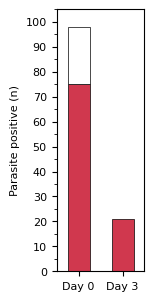

In [50]:
fig, bax = plt.subplots(1, 1, figsize=(W/3, W))

ct_barplot.plot(kind='bar', 
                stacked=True, 
                color=a724_cols,
                ec='black', lw=0.5,
                legend=False,
                ax=bax)
bax.set_xlabel("")
bax.set_ylabel("Parasite positive (n)")
bax.tick_params(axis='x', labelrotation=0)

bax.yaxis.set_major_locator(plt.MultipleLocator(10))
bax.yaxis.set_minor_locator(plt.MultipleLocator(5))
bax.set_ylim(0, 105)

if False:
    day3_positivity = 100 * ct_barplot.sum(1)['Day 3'] / ct_barplot.sum(1)['Day 0']
    bax.annotate(xy=(1,  ct_barplot.sum(1)['Day 3']+0.5),  va='bottom', ha='center',
                 text=f"{day3_positivity:.1f}%")

if save_results:
    fig.savefig(f"{DIR_FIGS}/plot.day3_barplot.pdf", dpi=600, bbox_inches="tight", pad_inches=0.5)
    fig.savefig(f"{DIR_FIGS}/plot.day3_barplot.png", dpi=600, bbox_inches="tight", pad_inches=0.5)

In [51]:
98/103

0.9514563106796117

In [52]:
17/21

0.8095238095238095

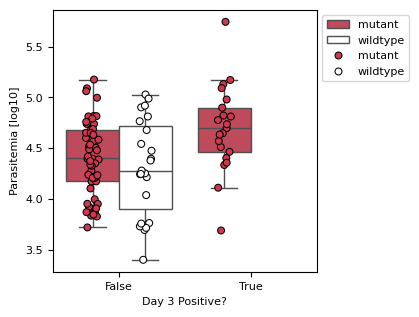

In [53]:
fig, ax = plt.subplots(1, 1, figsize=(W, W))

sns.boxplot(
    x="day3_pos",
    y="day0_parasite_density_log10",
    hue="day0_a724_mutant",
    palette=a724_cols,
    dodge=True,
    # edgecolor='black',
    # linewidth=0.75,
    showfliers=False,
    data=df_filter,
    
)

sns.stripplot(
    x="day3_pos",
    y="day0_parasite_density_log10",
    hue="day0_a724_mutant",
    palette=a724_cols,
    dodge=True,
    edgecolor='black',
    linewidth=0.75,
    data=df_filter
)

ax.set_xlabel("Day 3 Positive?")
ax.set_ylabel("Parasitemia [log10]")

ax.legend(bbox_to_anchor=(1, 1), loc='upper left')

if save_results:
    fig.savefig(f"{DIR_FIGS}/plot.day3_parasitemia.pdf", dpi=600, bbox_inches="tight", pad_inches=0.5)
    fig.savefig(f"{DIR_FIGS}/plot.day3_parasitemia.png", dpi=600, bbox_inches="tight", pad_inches=0.5)

# GET THE IQR

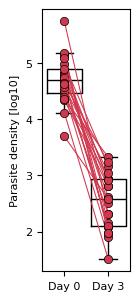

In [54]:
fig, ax = plt.subplots(1, 1, figsize=(W/3, W))

# Get day 3 positive data
_df = df_filter.query("day3_pos")

# Boxplot
ax.boxplot([_df["day0_parasite_density_log10"],
            _df["day3_parasite_density_log10"]],
           widths=0.8,
           tick_labels=["Day 0", "Day 3"],
           medianprops=dict(color='black'),
           showfliers=False)

# Connected plots
for _, row in _df.iterrows():
    if row['day3_pos']:
        ax.plot([1, 2],
                [row['day0_parasite_density_log10'], row['day3_parasite_density_log10']], 
                markeredgecolor='black',
                markeredgewidth=0.5,
                #markerfacecolor=a724_cols[0],
                color=a724_cols[0],
                #color='black',
                lw=0.75,
                marker='o',
                zorder=11,
                clip_on=False)
    else:
        ax.plot([1],
                [row['day0_parasite_density_log10']],
                markeredgecolor='black',
                markeredgewidth=0.5,
                color=a724_cols[0] if row['day0_a724_mutant'] == 'mutant' else a724_cols[1],
                marker='o', #'.',
                zorder=10,
                clip_on=False)
        
#ax.set_yscale("log")
ax.set_axisbelow(True)
ax.set_ylabel(r"Parasite density [log10]")
ax.set_xlim(0.5, 2.5)
# ax.set_ylim(0, 105)
ax.tick_params(axis='x', labelrotation=0)

if save_results:
    fig.savefig(f"{DIR_FIGS}/plot.day3.parasitemia.pdf", dpi=600, bbox_inches="tight", pad_inches=0.5)
    fig.savefig(f"{DIR_FIGS}/plot.day3.parasitemia.png", dpi=600, bbox_inches="tight", pad_inches=0.5)

In [55]:
_df[["day0_parasite_density_log10", "day3_parasite_density_log10"]].describe()

,day0_parasite_density_log10,day3_parasite_density_log10
count,21.000000,21.000000
mean,4.695821,2.534549
std,0.424609,0.505544
min,3.693815,1.505150
25%,4.466215,2.103804
50%,4.698970,2.582063
75%,4.899574,2.935003
max,5.742889,3.325105


In [56]:
10**2.161

144.87718535447618

In [57]:
v = (_df["day0_parasite_density_log10"] - _df["day3_parasite_density_log10"]).describe()

In [58]:
v

count    21.000000
mean      2.161272
std       0.689518
min       1.034560
25%       1.527974
50%       2.161151
75%       2.608793
max       3.426919
dtype: float64

In [59]:
10**1.034, 10**2.1611, 10**3.426

(10.81433951297938, 144.91054840012248, 2666.8586645214805)

### Intrahost selection
- For intrahost selection, we need to filter further, because we can only use samples that *also* were successfully sequenced on day 3.

In [60]:
N_day0passed = df_filter.shape[0]
N_day3seq = df_filter.query("day3_seqdone").shape[0]
N_day3seqpass = df_filter.query("day3_seqdone and day3_a724_mutant != 'failed'").shape[0]

df_intra = df_filter.query("day3_seqdone and day3_a724_mutant != 'failed'")

In [61]:
print(f"""
Inclusion for day 3 association with genotype:

Recall, we have {P(N_enrolled, df.shape[0])} patients enrolled.
Of those enrolled, {P(N_complete, N_enrolled)} returned on day 3.
Of those returning patients:
    {P(N_day0seq, N_complete)} have sequencing complete on day 0.
    {P(N_day0passed, N_day0seq)} are passing QC.
    {P(N_day3seq, N_day0passed)} have sequencing data on day 3.
    {P(N_day3seqpass, N_day3seq)} passed QC on day 3.

We care about those that were day 3 positive: {df_intra.day3_pos.sum()}.

    {P(df_filter.query('day3_pos and day3_seqdone and day0_seqdone and day3_a724_mutant != "failed"').shape[0], df_filter.query('day3_pos').shape[0])}

""")


Inclusion for day 3 association with genotype:

Recall, we have 188 (61.44%) of 306 patients enrolled.
Of those enrolled, 103 (54.79%) of 188 returned on day 3.
Of those returning patients:
    98 (95.15%) of 103 have sequencing complete on day 0.
    98 (100.00%) of 98 are passing QC.
    20 (20.41%) of 98 have sequencing data on day 3.
    20 (100.00%) of 20 passed QC on day 3.

We care about those that were day 3 positive: 17.

    17 (80.95%) of 21




- I don't really get this, need to clean it up

In [62]:
#df_filter.query("day3_pos").to_csv("table.day3_positive.csv", index=False)

##### Visualise

In [63]:
df_intra_pos = df_intra.query("day3_pos") # should I only show day 3+?
df_intra.shape[0], df_intra_pos.shape[0]

(20, 17)

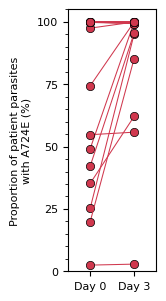

In [64]:
fig, ax = plt.subplots(1, 1, figsize=(W/3, W))

for _, row in df_intra_pos.iterrows():
    if row['day3_pos']:
        ax.plot(["Day 0", "Day 3"],
                [100*row['day0_a724_wsaf'], 100*row['day3_a724_wsaf']], 
                markeredgecolor='black',
                markeredgewidth=0.5,
                #markerfacecolor=a724_cols[0],
                color=a724_cols[0],
                #color='black',
                lw=0.75,
                marker='o',
                zorder=11,
                clip_on=False)
    else:
        ax.plot(["Day 0"],
                [100*row['day0_a724_wsaf']],
                markeredgecolor='black',
                markeredgewidth=0.5,
                color=a724_cols[0] if row['day0_a724_mutant'] == 'mutant' else a724_cols[1],
                marker='o', #'.',
                zorder=10,
                clip_on=False)
        
ax.set_axisbelow(True)
#ax.set_ylabel("Frequency of A724E\nwithin patient (%)")
ax.set_ylabel("Proportion of patient parasites\nwith A724E (%)")
ax.set_xlim(bax.get_xlim())
ax.set_ylim(0, 105)
ax.tick_params(axis='x', labelrotation=0)

ax.yaxis.set_major_locator(plt.MultipleLocator(25))
ax.yaxis.set_minor_locator(plt.MultipleLocator(5))


if save_results:
    fig.savefig(f"{DIR_FIGS}/plot.day3_intrahost.pdf", dpi=600, bbox_inches="tight", pad_inches=0.5)
    fig.savefig(f"{DIR_FIGS}/plot.day3_intrahost.png", dpi=600, bbox_inches="tight", pad_inches=0.5)

In [65]:
df_intra_pos["change_a724_wsaf"] = df_intra_pos["day3_a724_wsaf"] - df_intra_pos["day0_a724_wsaf"]

In [66]:
_FOCUS = ["sample_id", "day0_parasite_density", "day3_parasite_density",
          "day0_a724_gt", "day0_a724_wsaf", "day3_a724_wsaf",  "change_a724_wsaf",
          "day0_k13_all", "day0_k13_wsaf", "day3_k13_wsaf"
          ]

In [67]:
df_intra_pos.query("day3_a724_wsaf < 0.9 and change_a724_wsaf < 0.1")[_FOCUS]

,sample_id,day0_parasite_density,day3_parasite_density,day0_a724_gt,day0_a724_wsaf,day3_a724_wsaf,change_a724_wsaf,day0_k13_all,day0_k13_wsaf,day3_k13_wsaf
67,8036292,4941.0,382.0,0/1,0.547753,0.557905,0.010152,P667A-A724E,0.985615,0.990185
224,8036449,79355.0,813.0,0/1,0.024736,0.028684,0.003948,P667S-A724E,0.996552,0.999271


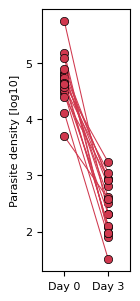

In [68]:
fig, ax = plt.subplots(1, 1, figsize=(W/3, W))

for _, row in df_intra_pos.iterrows():
    if row['day3_pos']:
        ax.plot(["Day 0", "Day 3"],
                [row['day0_parasite_density_log10'], row['day3_parasite_density_log10']], 
                markeredgecolor='black',
                markeredgewidth=0.5,
                #markerfacecolor=a724_cols[0],
                color=a724_cols[0],
                #color='black',
                lw=0.75,
                marker='o',
                zorder=11,
                clip_on=False)
    else:
        ax.plot(["Day 0"],
                [row['day0_parasite_density_log10']],
                markeredgecolor='black',
                markeredgewidth=0.5,
                color=a724_cols[0] if row['day0_a724_mutant'] == 'mutant' else a724_cols[1],
                marker='o', #'.',
                zorder=10,
                clip_on=False)
        
#ax.set_yscale("log")
ax.set_axisbelow(True)
ax.set_ylabel(r"Parasite density [log10]")
ax.set_xlim(bax.get_xlim())
# ax.set_ylim(0, 105)
ax.tick_params(axis='x', labelrotation=0)

# ax.yaxis.set_major_locator(plt.MultipleLocator(25))
# ax.yaxis.set_minor_locator(plt.MultipleLocator(5))

if save_results:
    fig.savefig(f"{DIR_FIGS}/plot.day3_intrahost.parasitemia.pdf", dpi=600, bbox_inches="tight", pad_inches=0.5)
    fig.savefig(f"{DIR_FIGS}/plot.day3_intrahost.parasitemia.png", dpi=600, bbox_inches="tight", pad_inches=0.5)

In [69]:
 df_filter.query("day3_pos")["day0_parasite_density_log10"] - df_filter.query("day3_pos")["day3_parasite_density_log10"]

1      1.887341
4      3.426919
16     2.608793
20     2.297040
25     2.161151
54     2.609065
67     1.111751
69     1.820641
99     2.563125
114    2.982165
126    2.199590
131    1.922240
137    3.194047
163    2.544917
165    1.463408
179    1.527974
210    3.118268
224    1.989484
255    1.520169
265    1.034560
276    1.404071
dtype: float64

- Note above is only those with sequencing data...

In [70]:
_df3 = df_filter.query('day3_pos') 
print(f"""
    In day 3 positive patients {_df3.shape[0]}:
        Pre-treatment parasitemia was: {get_median_and_iqrs(_df3['day0_parasite_density'])}
        Post-treatment parasitemia was: {get_median_and_iqrs(_df3['day3_parasite_density'])}
""")


    In day 3 positive patients 21:
        Pre-treatment parasitemia was: 50000.0 (29256.0 - 79355.0)
        Post-treatment parasitemia was: 382.0 (127.0 - 861.0)



- We are missing sequencing data from two patients, so they are not in `df_filter`, this should change soon.

##### Statistics
- Let's see if there is significant change in the WSAF after treatment

In [71]:
ss.wilcoxon(
    df_intra_pos['day0_a724_wsaf'],
    df_intra_pos['day3_a724_wsaf'],
)

WilcoxonResult(statistic=np.float64(20.0), pvalue=np.float64(0.013063960833068166))

In [72]:
df_intra_hetchange = df_intra_pos.query("day0_a724_gt == '0/1'")[["sample_id", "day0_a724_wsaf", "day3_a724_wsaf", "day0_a724_gt", "day3_a724_gt"]]
df_intra_hetchange

,sample_id,day0_a724_wsaf,day3_a724_wsaf,day0_a724_gt,day3_a724_gt
1,8036219,0.975191,0.999697,0/1,1/1
4,8036222,0.253204,0.951453,0/1,0/1
16,8036234,0.743960,1.000000,0/1,1/1
25,8036243,0.491935,0.999592,0/1,1/1
67,8036292,0.547753,0.557905,0/1,0/1
99,8036324,0.199352,0.853183,0/1,0/1
137,8036362,0.422251,0.955745,0/1,0/1
210,8036435,0.352594,0.621206,0/1,0/1
224,8036449,0.024736,0.028684,0/1,0/1


In [73]:
print(f"""
    Day 0 median WSAF: {get_median_and_iqrs(100*df_intra_hetchange['day0_a724_wsaf'])}
    Day 3 median WSAF: {get_median_and_iqrs(100*df_intra_hetchange['day3_a724_wsaf'])}
""")


    Day 0 median WSAF: 42.2 (25.3 - 54.8)
    Day 3 median WSAF: 95.1 (62.1 - 100.0)



- It increased in all eight cases
- It is >95% in 6/8

In [74]:
df_intra_hetchange[["day3_a724_wsaf", "day3_a724_wsaf"]].median()

day3_a724_wsaf    0.951453
day3_a724_wsaf    0.951453
dtype: float64

In [75]:
pd.crosstab(
    df_intra_pos["day0_a724_gt"],
    df_intra_pos["day3_a724_gt"],
    margins='All'
)

day3_a724_gt,0/1,1/1,All
day0_a724_gt,,,
0/1,6,3,9
1/1,0,8,8
All,6,11,17


In [76]:
def classify_hets(gt, d0, d3, tol: float = 0.02) -> str:
    if gt == '1/1':
        return None
    if np.isclose(d0, d3, atol=tol):
        return f"+/- {int(100*tol)}%"
    if d0 < d3:
        return "increase"
    if d0 > d3:
        return "decrease"

In [77]:
df_stable_intra = df_intra_pos[["sample_id", "age", "sex", "fever"] + [f"{d}_{s}" 
                                                                       for s in ['parasite_density', 'k13_all', 'a724_gt', 'a724_wsaf', 'k13_wsaf']
                                                                       for d in ['day0', 'day3']]]
df_stable_intra["het_change"] = [classify_hets(gt, d0, d3) 
                                 for (gt, d0, d3) in zip(df_stable_intra['day0_a724_gt'], 
                                                         df_stable_intra['day0_a724_wsaf'], 
                                                         df_stable_intra['day3_a724_wsaf'])]

In [78]:
renamer ={"sample_id": "Sample ID", 
          "age": "Age", 
                     "fever": "Fever",
                     "sex": "Sex",
          "day0_parasite_density": "Day 0 -- Parasite Density",
          "day3_parasite_density": "Day 0 -- Parasite Density",
                     "day0_k13_all": "Day 0 -- Pfkelch13",
                     "day0_k13_wsaf": "Day 0 -- Total WSAF", 
                     "day3_k13_wsaf": "Day 3 -- Total WSAF", 
                     "day0_a724_wsaf": "Day 0 -- A724E WSAF", 
                     "day3_a724_wsaf": "Day 3 -- A724E WSAF", 
                     "het_change": "Change?"}
          

In [79]:
df_stable_intra = df_stable_intra[renamer.keys()].rename(renamer, axis=1)# clean up this table, probably better to just do +/-

In [80]:
if True:
    df_stable_intra.to_excel(f"{DIR_TABLES}/stable_ceadriz.day3_pos_intrapatient.xlsx", index=False)

## Restrict analysis only to isolates with wildtype *Pfkelch13* or A724E

In [81]:
pd.crosstab(
    df_filter["day0_k13_all"],
    df_filter["day3_pos"],
    margins=True
)

day3_pos,False,True,All
day0_k13_all,,,
A675V-A724E,1,1,2
A724E,46,17,63
G533A,1,0,1
P441L-A724E,1,0,1
P667A,2,0,2
P667A-A724E,4,1,5
P667S,1,0,1
P667S-A724E,1,1,2
R622T-A724E,1,1,2


In [82]:
pd.crosstab(
    df_filter["day0_k13_all"],
    df_filter["day3_pos"],  
).loc[['WT', 'A724E']]

day3_pos,False,True
day0_k13_all,,
WT,19,0
A724E,46,17


*Univariable*

In [83]:
keep_a724 = ["WT", "A724E"] # we remove any isolate with other K13 mutations
df_filter_onlya724 = df_filter.query("day0_k13_all in @keep_a724")

In [84]:
_df_bias = (df_filter_onlya724.groupby("day3_pos")
    .agg(
        n_patients=pd.NamedAgg("sample_id", lambda x: len(x)),
        age = pd.NamedAgg("age", get_median_and_iqrs),
        day0_parasite_density_thousands = pd.NamedAgg("day0_parasite_density", lambda x: get_median_and_iqrs(x/10**3)),
        sex_female=pd.NamedAgg("sex", lambda x: get_number_and_percent(x, "F")),
        fever=pd.NamedAgg("fever", lambda x: get_number_and_percent(x, "Yes")),
        wildtype_A724E=pd.NamedAgg("day0_a724_mutant", lambda x: get_number_and_percent(x, "wildtype")),
        mutant_A724E=pd.NamedAgg("day0_a724_mutant", lambda x: get_number_and_percent(x, "mutant")),   
    )
    #.reset_index()
).transpose()

In [85]:
tester = HypothesisTester(data=df_filter_onlya724, groups="day3_pos")
_df_stats = pd.DataFrame(
    [
        UniResult("n_patients", "-", "-"),
        UniResult("age", "Mann-Whitney $U$", tester.mannu("age").pvalue),
        UniResult("day0_parasite_density_thousands", "Mann-Whitney $U$", tester.mannu("day0_parasite_density").pvalue),
        UniResult("sex_female", "$X^2$", tester.chisq("sex").pvalue),
        UniResult("fever", "$X^2$", tester.chisq("fever").pvalue),
        UniResult("wildtype_A724E", "Fisher's Exact", "See below."),
        UniResult("mutant_A724E", "Fisher's Exact", tester.fisher("day0_a724_mutant").pvalue),
        
        # UniResult("sex_female", "Fisher's Exact", fisher_pvalue("sex")),
        # UniResult("fever", "Fisher's Exact", fisher_pvalue("fever")),
    ]
)
_df_stats.set_index('variable', inplace=True)

In [86]:
# But why am I doing this comparison? I want to compare if there is a difference in day 3+ between the two sets
df_day3_bias = pd.concat([_df_bias, _df_stats], axis=1)
df_day3_bias = df_day3_bias.rename(INDEX_NAMES).rename(COLUMN_NAMES, axis=1)
df_day3_bias

,Negative on Day 3,Positive on Day 3,Test,P
N,65,17,-,-
Median Age (IQR) - yr,11.5 (7.0 - 18.0),11.0 (6.0 - 16.0),Mann-Whitney $U$,0.534
Median parasity density (IQR) - mm$^3$,25.0 (15.0 - 48.7),50.0 (32.6 - 66.4),Mann-Whitney $U$,0.005
Female sex - n (%),33 (50.8),10 (58.8),$X^2$,0.749
Fever - n (%),11 (16.9),6 (35.3),$X^2$,0.233
724A (Wildtype),19 (29.2),0 (0.0),Fisher's Exact,See below.
724E (Mutant),46 (70.8),17 (100.0),Fisher's Exact,0.009


*Multivariable*

In [87]:
df_filter_onlya724["day0_k13_all"].value_counts(), df_filter_onlya724["day0_k13_all"].value_counts().sum()

(day0_k13_all
 A724E    63
 WT       19
 Name: count, dtype: int64,
 np.int64(82))

In [88]:
_df = df_filter_onlya724[["age", "day0_parasite_density_log10", "sex", "fever", "day0_a724_mutant", "outcome"]].dropna()
X = sm.add_constant(
    pd.concat([
        _df[["age", "day0_parasite_density_log10"]],
        #_df[["day0_parasite_density_log10"]],
        pd.get_dummies(_df["sex"], prefix="sex", drop_first=True),
        pd.get_dummies(_df["fever"], prefix="fever", drop_first=True),    
        pd.DataFrame([True if v == 'mutant' else False for v in _df["day0_a724_mutant"]],
                     columns=["724_mutant"], index=_df.index) # done manually to encode mutant as 1
    ],
              axis=1)
)
y = _df["outcome"]

In [89]:
model_onlya724 = FirthLogit(y, X).fit()
print(model_onlya724.summary())

                      Firth Logistic Regression Results                       
Solver:            Newton-Raphson      No. Observations:          77
Converged:         True                No. Events:                17
No. Iterations:    11                  Df Model:                   5
Log-Likelihood:    -26.102             Df Residual:               71
                  coef   std err         z     P>|z|    [0.025    0.975]
------------------------------------------------------------------------------
       const  -12.6584    4.4678   -2.8332    0.0015  -23.6427   -4.3814
         age   -0.0123    0.0289   -0.4248    0.6782   -0.0801    0.0440
day0_parasit    2.1062    0.8929    2.3587    0.0133    0.4108    4.2226
       sex_M   -0.4975    0.5841   -0.8517    0.4078   -1.7205    0.6806
   fever_Yes    0.4818    0.6489    0.7424    0.4741   -0.8705    1.7901
  724_mutant    2.4426    1.4099    1.7325    0.0281    0.2077    7.3618
P-values: Penalized likelihood ratio test | CIs: Profil

In [90]:
df_firth_onlya724 = convert_logistic_to_output_table(model_onlya724)
df_firth_onlya724

,Coefficient (SE),Odds Ratio (95% CI),P
Covariate,,,
Intercept,-12.66 (4.47),0.0 (0.0-0.0),0.001
Age,-0.01 (0.03),1.0 (0.9-1.0),0.678
Parasity density [log10],2.11 (0.89),8.2 (1.5-68.2),0.013
Sex,-0.5 (0.58),0.6 (0.2-2.0),0.408
Fever,0.48 (0.65),1.6 (0.4-6.0),0.474
724E (Mutant),2.44 (1.41),11.5 (1.2-1574.7),0.028


In [91]:
if save_results:
    # Univariate
    df_day3_bias.to_csv(f"{DIR_TABLES}/stable_ceadriz.day3_univariate.only_a724e.csv")
    df_day3_bias.to_csv(f"{DIR_TABLES}/stable_ceadriz.day3_univariate.only_a724e.xlsx")

    # Logistic, with Firth
    df_firth_onlya724.to_csv(f"{DIR_TABLES}/stable_ceadriz.day3_multivariate_firths.only_a724e.csv")
    df_firth_onlya724.to_excel(f"{DIR_TABLES}/stable_ceadriz.day3_multivariate_firths.only_a724e.xlsx")

In [92]:
df_filter["day0_k13_all"].value_counts()

day0_k13_all
A724E          63
WT             19
P667A-A724E     5
P667A           2
R622T-A724E     2
A675V-A724E     2
P667S-A724E     2
G533A           1
P441L-A724E     1
P667S           1
Name: count, dtype: int64

In [93]:
# Day 3 data
df_day3_data = df_filter[["sample_id", "age", "sex", "fever", "day0_k13_all", "day0_k13_wsaf", "day3_k13_wsaf", "day3_pos"]].sort_values(["sample_id"])
df_day3_data["age"] = df_day3_data["age"].round(0)
df_day3_data["day0_k13_all"] = df_day3_data["day0_k13_all"].str.replace("-", "+")
df_day3_data["day0_k13_wsaf"] = df_day3_data["day0_k13_wsaf"].round(2)
df_day3_data["day3_k13_wsaf"] = df_day3_data["day3_k13_wsaf"].round(2)
df_day3_data.rename({"sample_id": "Sample ID", 
                     "age": "Age", 
                     "fever": "Fever",
                     "sex": "Sex",
                     "day0_k13_all": "Day 0 -- Pfkelch13",
                     "day0_k13_wsaf": "Day 0 -- WSAF", 
                     "day3_k13_wsaf": "Day 3 -- WSAF", 
                     "day3_pos": "Day 3 Positive"}, 
                    axis=1, inplace=True)

In [94]:
if True:
    df_day3_data.to_excel(f"{DIR_TABLES}/stable_ceadriz.day3_data.xlsx", index=False)